In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [23]:
df = pd.read_csv("../Datasets/placement_predict_50k Dataset.csv")

In [24]:
print("Dataset shape: ", df.shape)
df.head()

Dataset shape:  (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [25]:
print(df.columns.tolist())
print(df["PlacementStatus"].value_counts())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [26]:
target = "PlacementStatus"
X = df.drop(columns=target)
y = df[target]

In [27]:
print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (50000, 31)
y shape:  (50000,)


In [28]:
print("Target Distribution: ")
print(y.value_counts())

Target Distribution: 
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [29]:
X = pd.get_dummies(X, drop_first=True)
print("Encoded X shape: ", X.shape)

Encoded X shape:  (50000, 47)


In [30]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

In [31]:
print("X train: ", X_train.shape)
print("X val: ", X_val.shape)
print("y train: ", y_train.shape)
print("y val: ", y_val.shape)

X train:  (40000, 47)
X val:  (10000, 47)
y train:  (40000,)
y val:  (10000,)


In [32]:
print("Missing values in X: ")
print(X.isna().sum().sort_values(ascending=False).head(20))

Missing values in X: 
MockInterviewScore    4957
Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
SGPA_Sem1                0
StudentID                0
SGPA_Sem6                0
SGPA_Sem7                0
CGPA                     0
SGPA_Sem8                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem2                0
Certifications           0
Projects                 0
Internships              0
AttendancePercent        0
Publications             0
dtype: int64


In [33]:
X = X.replace([np.inf, -np.inf], np.nan)
print("Missing values after replacing infinity: ", X.isna().sum().sum())

Missing values after replacing infinity:  19976


In [35]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

print("Training missing values:",
      np.isnan(X_train_imputed).sum())

print("Validation missing values:",
      np.isnan(X_val_imputed).sum())


Training missing values: 0
Validation missing values: 0


In [37]:
np.isnan(X_train_imputed).sum()
np.isnan(X_val_imputed).sum()

np.int64(0)

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.fit_transform(X_val_imputed)

print("X_train_scaled: ", X_train_scaled.shape)
print("X_val_scaled: ", X_val_scaled.shape)

X_train_scaled:  (40000, 47)
X_val_scaled:  (10000, 47)


In [39]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

In [40]:
from sklearn.linear_model import LogisticRegression


def compare_regularisation(X_train, y_train, X_val, y_val, C_values):

    results = []

    for C in C_values:

        # LASSO - L1
        lasso = LogisticRegression(
            penalty="l1",
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        lasso.fit(X_train, y_train)

        lasso_pred = lasso.predict(X_val)

        lasso_acc = accuracy_score(
            y_val,
            lasso_pred
        )

        lasso_nonzero = np.sum(
            np.abs(lasso.coef_) > 1e-6
        )

        # RIDGE - L2
        ridge = LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        ridge.fit(X_train, y_train)

        ridge_pred = ridge.predict(X_val)

        ridge_acc = accuracy_score(
            y_val,
            ridge_pred
        )

        ridge_nonzero = np.sum(
            np.abs(ridge.coef_) > 1e-6
        )

        # ELASTIC NET - L1 + L2
        elastic = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=0.5,
            solver="saga",
            max_iter=5000,
            random_state=42
        )

        elastic.fit(X_train, y_train)

        elastic_pred = elastic.predict(X_val)

        elastic_acc = accuracy_score(
            y_val,
            elastic_pred
        )

        results.append({
            "C": C,
            "Lasso_val_acc": lasso_acc,
            "Ridge_val_acc": ridge_acc,
            "ElasticNet_val_acc": elastic_acc,
            "Lasso_nonzero": lasso_nonzero,
            "Ridge_nonzero": ridge_nonzero
        })

    return pd.DataFrame(results)


In [43]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results_df = compare_regularisation(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    C_values
)

results_df


D:\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
D:\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set t

,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
0,0.001,0.9686,0.9456,0.9778,11,47
1,0.010,0.9971,0.9912,0.9954,14,47
2,0.100,0.9981,0.9974,0.9976,24,47
3,1.000,0.9981,0.9981,0.9981,40,47
4,10.000,0.9981,0.9981,0.9981,47,47
5,100.000,0.9982,0.9982,0.9982,47,47


In [44]:
best_lasso = results_df.loc[
    results_df["Lasso_val_acc"].idxmax()
]

print("Best Lasso:")
print(best_lasso)

best_ridge = results_df.loc[
    results_df["Ridge_val_acc"].idxmax()
]

print("Best Ridge:")
print(best_ridge)

best_elastic = results_df.loc[
    results_df["ElasticNet_val_acc"].idxmax()
]

print("Best Elastic Net:")
print(best_elastic)


Best Lasso:
C                     100.0000
Lasso_val_acc           0.9982
Ridge_val_acc           0.9982
ElasticNet_val_acc      0.9982
Lasso_nonzero          47.0000
Ridge_nonzero          47.0000
Name: 5, dtype: float64
Best Ridge:
C                     100.0000
Lasso_val_acc           0.9982
Ridge_val_acc           0.9982
ElasticNet_val_acc      0.9982
Lasso_nonzero          47.0000
Ridge_nonzero          47.0000
Name: 5, dtype: float64
Best Elastic Net:
C                     100.0000
Lasso_val_acc           0.9982
Ridge_val_acc           0.9982
ElasticNet_val_acc      0.9982
Lasso_nonzero          47.0000
Ridge_nonzero          47.0000
Name: 5, dtype: float64


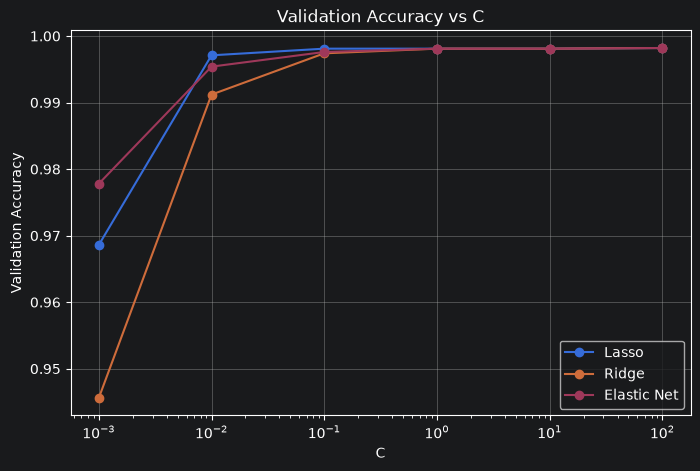

In [45]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(True)

plt.show()
